   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.4 MB/s eta 0:00:00
Using device: cuda
✅ Part A    : /kaggle/input/datasets/peesarisathvikreddy/isic2018-seg-part-a
✅ Part B    : /kaggle/input/datasets/peesarisathvikreddy/isic2018-seg-part-b
✅ ISIC      : /kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation
Train images : 2596 files
Train masks  : 2596 files

Train : 2075 | Test : 519
Client sizes : [688, 687, 700]

Val:415 | Test:519

Using SMP U-Net


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Output shape: torch.Size([2, 1, 256, 256])

RUNNING DITTO — 20 rounds
  Round 1/20 ditto → Dice:0.8072  IoU:0.7103
  Round 2/20 ditto → Dice:0.8620  IoU:0.7817
  Round 3/20 ditto → Dice:0.8829  IoU:0.8112
  Round 4/20 ditto → Dice:0.8915  IoU:0.8232
  Round 5/20 ditto → Dice:0.8967  IoU:0.8303
  Round 6/20 ditto → Dice:0.9034  IoU:0.8387
  Round 7/20 ditto → Dice:0.9070  IoU:0.8451
  Round 8/20 ditto → Dice:0.9045  IoU:0.8421
  Round 9/20 ditto → Dice:0.9043  IoU:0.8414
  Round 10/20 ditto → Dice:0.9056  IoU:0.8439
  Round 11/20 ditto → Dice:0.9068  IoU:0.8450
  Round 12/20 ditto → Dice:0.9129  IoU:0.8551
  Round 13/20 ditto → Dice:0.9150  IoU:0.8565
  Round 14/20 ditto → Dice:0.9172  IoU:0.8601
  Round 15/20 ditto → Dice:0.9182  IoU:0.8639
  Round 16/20 ditto → Dice:0.9152  IoU:0.8559
  Round 17/20 ditto → Dice:0.9152  IoU:0.8579
  Round 18/20 ditto → Dice:0.9198  IoU:0.8652
  Round 19/20 ditto → Dice:0.9177  IoU:0.8641
  Round 20/20 ditto → Dice:0.9172  IoU:0.8621

✅ ditto → Dice=0.8

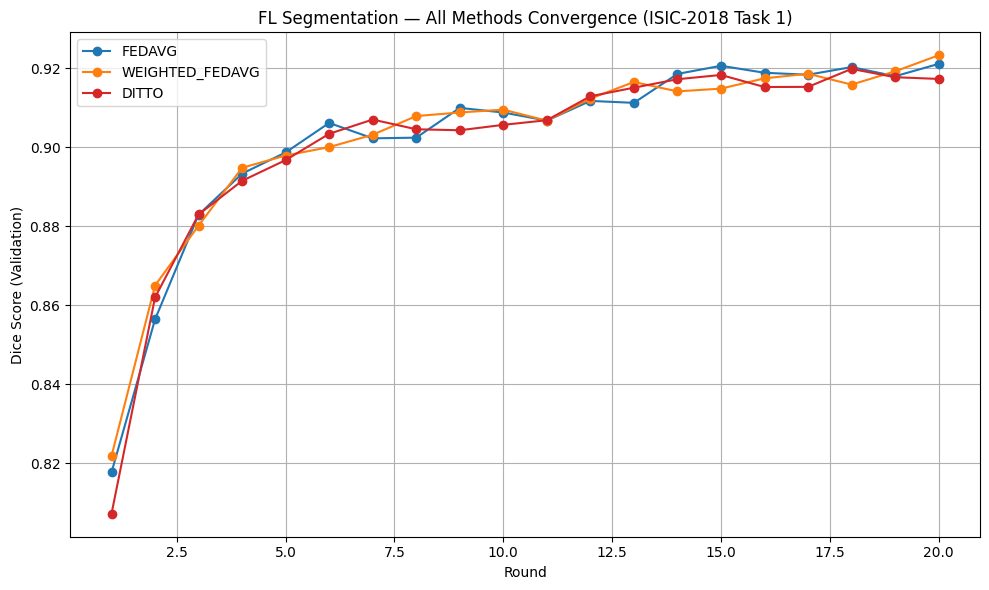


NOTEBOOK 1C COMPLETE
Files in /kaggle/working/:
  __notebook__.ipynb                            0.0 MB
  client_0_test_split.csv                       0.0 MB
  client_0_train.csv                            0.2 MB
  client_1_test_split.csv                       0.0 MB
  client_1_train.csv                            0.2 MB
  client_2_test_split.csv                       0.0 MB
  client_2_train.csv                            0.2 MB
  client_ditto_0.pth                            57.4 MB
  client_ditto_1.pth                            57.4 MB
  client_ditto_2.pth                            57.4 MB
  client_fedavg_0.pth                           57.4 MB
  client_fedavg_1.pth                           57.4 MB
  client_fedavg_2.pth                           57.4 MB
  client_fedprox_0.pth                          57.4 MB
  client_fedprox_1.pth                          57.4 MB
  client_fedprox_2.pth                          57.4 MB
  client_weighted_fedavg_0.pth                  57.4 MB
  clie

In [1]:
# ==========================================
# NOTEBOOK 1C: FL SEGMENTATION — DITTO ONLY
# Requires: part-a + part-b + ISIC-2018 as inputs
# ==========================================

!pip install -q scikit-learn tqdm segmentation-models-pytorch

import os, copy, json, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image
from collections import OrderedDict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. HARDCODED PATHS
# ==========================================
PART_A    = "/kaggle/input/datasets/peesarisathvikreddy/isic2018-seg-part-a"
PART_B    = "/kaggle/input/datasets/peesarisathvikreddy/isic2018-seg-part-b"
ISIC_PATH = "/kaggle/input/datasets/tschandl/isic2018-challenge-task1-data-segmentation"

TRAIN_IMG_DIR  = os.path.join(ISIC_PATH, "ISIC2018_Task1-2_Training_Input")
TRAIN_MASK_DIR = os.path.join(ISIC_PATH, "ISIC2018_Task1_Training_GroundTruth")

print(f"✅ Part A    : {PART_A}")
print(f"✅ Part B    : {PART_B}")
print(f"✅ ISIC      : {ISIC_PATH}")
print(f"Train images : {len(os.listdir(TRAIN_IMG_DIR))} files")
print(f"Train masks  : {len(os.listdir(TRAIN_MASK_DIR))} files")

# ==========================================
# 2. RELOAD META + DATA FROM PART A
# ==========================================
with open(os.path.join(PART_A, "meta.json")) as f:
    meta = json.load(f)

majority_classes_per_client = meta['majority_classes_per_client']
IMG_SIZE                    = meta['img_size']
MAIN_FRAC                   = meta['main_frac']

train_df   = pd.read_csv(os.path.join(PART_A, "train_df.csv"))
test_df    = pd.read_csv(os.path.join(PART_A, "test_df.csv"))
client_dfs = [pd.read_csv(os.path.join(PART_A, f"client_{i}_train.csv"))
              for i in range(3)]
client_sizes = [len(c) for c in client_dfs]

print(f"\nTrain : {len(train_df)} | Test : {len(test_df)}")
print(f"Client sizes : {client_sizes}")

# ==========================================
# 3. TRANSFORMS + DATASET
# ==========================================
img_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])
mask_tf = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE, IMG_SIZE),
        interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

class SegDataset(Dataset):
    def __init__(self, df, img_tf=None, mask_tf=None, noise=0.0):
        self.df=df.reset_index(drop=True)
        self.img_tf=img_tf; self.mask_tf=mask_tf; self.noise=noise
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=Image.open(row['image']).convert("RGB")
        mask=Image.open(row['mask']).convert("L")
        if self.img_tf:  img=self.img_tf(img)
        if self.mask_tf: mask=self.mask_tf(mask)
        mask=(mask>0.5).float()
        if self.noise>0:
            img+=torch.randn_like(img)*self.noise/255.0
            img=torch.clamp(img,0,1)
        return img, mask, row['size_label']

def make_loader(df, noise=0.0, batch_size=8, shuffle=False):
    return DataLoader(
        SegDataset(df, img_tf, mask_tf, noise),
        batch_size=batch_size, shuffle=shuffle,
        num_workers=2, pin_memory=True)

NOISE       = [0.0, 15.0, 10.0]
dataloaders = [make_loader(cdf, noise=NOISE[i])
               for i, cdf in enumerate(client_dfs)]
val_df      = train_df.sample(frac=0.2, random_state=42)
val_loader  = make_loader(val_df)
test_loader = make_loader(test_df)
print(f"\nVal:{len(val_df)} | Test:{len(test_df)}")

# ==========================================
# 4. MODEL
# ==========================================
try:
    import segmentation_models_pytorch as smp
    def get_model():
        return smp.Unet(
            encoder_name="resnet18", encoder_weights="imagenet",
            in_channels=3, classes=1).to(device)
    print("\nUsing SMP U-Net")
except ImportError:
    class DoubleConv(nn.Module):
        def __init__(self,ic,oc):
            super().__init__()
            self.c=nn.Sequential(
                nn.Conv2d(ic,oc,3,padding=1,bias=False),
                nn.BatchNorm2d(oc),nn.ReLU(inplace=True),
                nn.Conv2d(oc,oc,3,padding=1,bias=False),
                nn.BatchNorm2d(oc),nn.ReLU(inplace=True))
        def forward(self,x): return self.c(x)
    class UNet(nn.Module):
        def __init__(self,features=[64,128,256,512]):
            super().__init__()
            self.downs=nn.ModuleList(); self.ups=nn.ModuleList()
            self.pool=nn.MaxPool2d(2); c=3
            for f in features: self.downs.append(DoubleConv(c,f)); c=f
            self.bottleneck=DoubleConv(features[-1],features[-1]*2)
            for f in reversed(features):
                self.ups.append(nn.ConvTranspose2d(f*2,f,2,stride=2))
                self.ups.append(DoubleConv(f*2,f))
            self.final=nn.Conv2d(features[0],1,1)
        def forward(self,x):
            skips=[]
            for d in self.downs: x=d(x); skips.append(x); x=self.pool(x)
            x=self.bottleneck(x); skips=skips[::-1]
            for i in range(0,len(self.ups),2):
                x=self.ups[i](x); sk=skips[i//2]
                if x.shape!=sk.shape: x=F.interpolate(x,size=sk.shape[2:])
                x=self.ups[i+1](torch.cat([sk,x],dim=1))
            return self.final(x)
    def get_model(): return UNet().to(device)
    print("\nUsing custom U-Net")

_m=get_model(); _x=torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(device)
print(f"Output shape: {_m(_x).shape}"); del _m,_x
torch.cuda.empty_cache()

# ==========================================
# 5. LOSS + METRICS
# ==========================================
class DiceBCELoss(nn.Module):
    def __init__(self,smooth=1e-6):
        super().__init__()
        self.bce=nn.BCEWithLogitsLoss(); self.s=smooth
    def forward(self,logits,targets):
        bce=self.bce(logits,targets); p=torch.sigmoid(logits)
        i=(p*targets).sum(dim=(2,3))
        d=1-(2*i+self.s)/(p.sum(dim=(2,3))+targets.sum(dim=(2,3))+self.s)
        return bce+d.mean()

criterion = DiceBCELoss()

def compute_metrics(logits, masks, thr=0.5):
    preds=(torch.sigmoid(logits)>thr).float(); s=1e-6
    tp=(preds*masks).sum(dim=(2,3))
    fp=(preds*(1-masks)).sum(dim=(2,3))
    fn=((1-preds)*masks).sum(dim=(2,3))
    tn=((1-preds)*(1-masks)).sum(dim=(2,3))
    return {
        'dice':        ((2*tp+s)/(2*tp+fp+fn+s)).mean().item(),
        'iou':         ((tp+s)/(tp+fp+fn+s)).mean().item(),
        'pixel_acc':   ((tp+tn+s)/(tp+fp+fn+tn+s)).mean().item(),
        'sensitivity': ((tp+s)/(tp+fn+s)).mean().item(),
        'specificity': ((tn+s)/(tn+fp+s)).mean().item(),
    }

def evaluate(model, loader):
    model.eval(); all_m=[]
    with torch.no_grad():
        for batch in loader:
            imgs,masks=batch[0].to(device),batch[1].to(device)
            all_m.append(compute_metrics(model(imgs),masks))
    return {k:float(np.mean([m[k] for m in all_m])) for k in all_m[0]}

# ==========================================
# 6. LOCAL TRAINING + AGGREGATION
# ==========================================
def train_local(model, loader, gw,
                local_epochs=3, lr=1e-4, ditto_lambda=0.0):
    model.train()
    opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-5)
    for _ in range(local_epochs):
        for batch in loader:
            imgs,masks=batch[0].to(device),batch[1].to(device)
            opt.zero_grad(); loss=criterion(model(imgs),masks)
            if ditto_lambda>0:
                loss+=ditto_lambda*sum(
                    torch.sum((p-gw[n].to(device))**2)
                    for n,p in model.named_parameters()
                    if n in gw and p.dtype.is_floating_point)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step()
    return {k:v.cpu().clone() for k,v in model.state_dict().items()}

def fedavg_agg(lw):
    avg=OrderedDict()
    for k in lw[0]:
        t=[w[k] for w in lw]
        avg[k]=torch.stack(t).mean(0) \
               if t[0].dtype.is_floating_point else t[0].clone()
    return avg

# ==========================================
# 7. DITTO TRAINING — 20 ROUNDS
# ==========================================
ROUNDS       = 20
LOCAL_EPOCHS = 3
LR           = 1e-4

print(f"\n{'='*50}")
print(f"RUNNING DITTO — {ROUNDS} rounds")
print(f"{'='*50}")

gm  = get_model()
gw  = {k:v.cpu() for k,v in gm.state_dict().items()}
cms = [get_model() for _ in range(3)]
pw  = [{k:v.cpu().clone() for k,v in gm.state_dict().items()}
       for _ in range(3)]
best_dice, best_gw = -1.0, None
history = []

for rnd in range(ROUNDS):
    # Step A — clean FedAvg for global (no Ditto penalty)
    gl=[]
    for cid,loader in enumerate(dataloaders):
        tmp=get_model(); tmp.load_state_dict(gw,strict=True)
        gl.append(train_local(tmp,loader,gw,
                              local_epochs=LOCAL_EPOCHS,lr=LR))
    gw=fedavg_agg(gl)
    gm.load_state_dict(gw,strict=True)

    # Step B — personal update with Ditto penalty
    for cid,loader in enumerate(dataloaders):
        cms[cid].load_state_dict(pw[cid],strict=True)
        pw[cid]=train_local(cms[cid],loader,gw,
                            local_epochs=LOCAL_EPOCHS,lr=LR,
                            ditto_lambda=0.005)

    val_m=evaluate(gm,val_loader)
    history.append({
        'round':rnd, 'aggregation':'ditto',
        'dice':val_m['dice'], 'iou':val_m['iou'],
        'pixel_acc':val_m['pixel_acc'],
        'sensitivity':val_m['sensitivity'],
        'specificity':val_m['specificity'],
    })
    print(f"  Round {rnd+1}/{ROUNDS} ditto → "
          f"Dice:{val_m['dice']:.4f}  IoU:{val_m['iou']:.4f}")

    if val_m['dice']>best_dice:
        best_dice=val_m['dice']
        best_gw=copy.deepcopy(gw)

gm.load_state_dict(best_gw,strict=True)

# Save personal client checkpoints
for cid in range(3):
    sm=get_model()
    sm.load_state_dict(pw[cid],strict=True)
    torch.save(sm.state_dict(),
               f"/kaggle/working/client_ditto_{cid}.pth")

torch.save(gm.state_dict(),"/kaggle/working/final_model_ditto.pth")
fm_ditto=evaluate(gm,test_loader)
print(f"\n✅ ditto → Dice={fm_ditto['dice']:.4f}  "
      f"IoU={fm_ditto['iou']:.4f}")

# ==========================================
# 8. SAVE DITTO HISTORY
# ==========================================
pd.DataFrame(history).to_csv(
    "/kaggle/working/fl_results_part_c.csv", index=False)

# ==========================================
# 9. COPY ALL PART A + PART B FILES FORWARD
# So Notebook 2 only needs Part C as input
# ==========================================
print("\nCopying Part A files...")
files_a = [
    "test_df.csv", "train_df.csv", "meta.json",
    "fl_results_part_a.csv",
    "client_0_train.csv", "client_1_train.csv", "client_2_train.csv",
    "client_0_test_split.csv",
    "client_1_test_split.csv",
    "client_2_test_split.csv",
    "noniid_distribution.png",
]
for fname in files_a:
    src=os.path.join(PART_A, fname)
    if os.path.exists(src):
        shutil.copy(src, f"/kaggle/working/{fname}")
        print(f"  ✅ {fname}")
    else:
        print(f"  ⚠️  {fname} not in Part A")

print("\nCopying Part B files...")
files_b = [
    "fl_results_part_b.csv",
    "final_model_fedavg.pth",
    "final_model_weighted_fedavg.pth",
    "final_model_fedprox.pth",
    "client_fedavg_0.pth", "client_fedavg_1.pth", "client_fedavg_2.pth",
    "client_weighted_fedavg_0.pth",
    "client_weighted_fedavg_1.pth",
    "client_weighted_fedavg_2.pth",
    "client_fedprox_0.pth",
    "client_fedprox_1.pth",
    "client_fedprox_2.pth",
    "convergence_part_a.png",
    "convergence_part_b.png",
]
for fname in files_b:
    # Check Part B first, then fall back to Part A
    src_b=os.path.join(PART_B, fname)
    src_a=os.path.join(PART_A, fname)
    if os.path.exists(src_b):
        shutil.copy(src_b, f"/kaggle/working/{fname}")
        print(f"  ✅ {fname} (from Part B)")
    elif os.path.exists(src_a):
        shutil.copy(src_a, f"/kaggle/working/{fname}")
        print(f"  ✅ {fname} (from Part A)")
    else:
        print(f"  ⚠️  {fname} not found in Part A or B")

# ==========================================
# 10. MERGE ALL HISTORY INTO ONE CSV
# ==========================================
hist_parts = []
for part, fname in [
    ('A', "fl_results_part_a.csv"),
    ('B', "fl_results_part_b.csv"),
    ('C', "fl_results_part_c.csv"),
]:
    fpath = f"/kaggle/working/{fname}"
    if os.path.exists(fpath):
        hist_parts.append(pd.read_csv(fpath))
        print(f"  ✅ Loaded {fname}")
    else:
        print(f"  ⚠️  {fname} missing")

if hist_parts:
    pd.concat(hist_parts, ignore_index=True).to_csv(
        "/kaggle/working/fl_results_all_methods.csv", index=False)
    print("✅ fl_results_all_methods.csv merged")

# ==========================================
# 11. CONVERGENCE PLOT — ALL 4 METHODS
# ==========================================
df_all = pd.read_csv("/kaggle/working/fl_results_all_methods.csv")
METHOD_NAMES = ['fedavg','weighted_fedavg','fedprox','ditto']
colors = {
    'fedavg':          '#1f77b4',
    'weighted_fedavg': '#ff7f0e',
    'fedprox':         '#2ca02c',
    'ditto':           '#d62728',
}

plt.figure(figsize=(10,6))
for name in METHOD_NAMES:
    sub=df_all[df_all['aggregation']==name]
    if len(sub)>0:
        plt.plot(sub['round']+1, sub['dice'],
                 marker='o', color=colors[name], label=name.upper())
plt.xlabel('Round'); plt.ylabel('Dice Score (Validation)')
plt.title('FL Segmentation — All Methods Convergence (ISIC-2018 Task 1)')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("/kaggle/working/convergence_all_methods.png", dpi=150)
plt.show()

# ==========================================
# 12. FINAL SUMMARY
# ==========================================
print("\n" + "="*60)
print("NOTEBOOK 1C COMPLETE")
print("="*60)
print("Files in /kaggle/working/:")
for f in sorted(os.listdir("/kaggle/working/")):
    size = os.path.getsize(f"/kaggle/working/{f}")
    print(f"  {f:<45} {size/1e6:.1f} MB")

print("\n➡  Save this output as: 'isic2018-seg-part-c'")
print("➡  Notebook 2 only needs Part C + ISIC-2018 as inputs")
print("   (Part C already contains everything from Part A and B)")